# Regression on 1% Sample

This notebook keeps only the essential preprocessing and modeling steps on a 1% sample of the dataset so it runs faster and stays easier to follow.

## Learning Flow

1. Load and inspect a smaller sample of the dataset.
2. Clean missing values and define feature types.
3. Build preprocessing and split the data.
4. Tune the model with cross-validation.
5. Evaluate the predictions and visualize the results.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Step 1: load the data and keep only a 1% sample for a faster lesson-friendly workflow
full_df = pd.read_csv('genz_social_media_usage_1M.csv').drop_duplicates()
df = full_df.sample(frac=0.01, random_state=42).reset_index(drop=True)

target = 'mental_health_score'
num_cols = [c for c in df.select_dtypes(include='number').columns.tolist() if c != target]
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

print('Original shape:', full_df.shape)
print('Shape after 1% sampling:', df.shape)
print('Target column:', target)
print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

Original shape: (1000000, 12)
Shape after 1% sampling: (10000, 12)
Target column: mental_health_score
Numeric columns: ['age', 'daily_usage_hours', 'num_platforms_used', 'avg_session_minutes', 'night_usage', 'screen_time_before_sleep']
Categorical columns: ['gender', 'country', 'primary_platform', 'purpose', 'addiction_level']


In [43]:
# Basic preprocessing
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
])

# Train on the sampled data only
X_train_sample = X_train.sample(frac=1.0, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

print('Train shape:', X_train_sample.shape)
print('Test shape:', X_test.shape)

Train shape: (8000, 11)
Test shape: (2000, 11)


## Step 2: Clean and Prepare the Features

We fill missing values first so the model receives complete numeric and categorical inputs.

In [44]:
pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

param_dist = {
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_iter': [50, 100, 150],
    'model__max_depth': [3, 5, None],
    'model__max_leaf_nodes': [15, 31, 63],
    'model__min_samples_leaf': [10, 20, 40],
    'model__l2_regularization': [0.0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train_sample, y_train_sample)
best_model = search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print('Best params:', search.best_params_)
print('MAE:', round(mae, 4))
print('RMSE:', round(rmse, 4))
print('R2:', round(r2, 4))

Best params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_iter': 150, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.0}
MAE: 0.7798
RMSE: 0.969
R2: 0.5907


## Step 3: Tune the Model

We use `RandomizedSearchCV` to test a small set of useful hyperparameters for `HistGradientBoostingRegressor`.

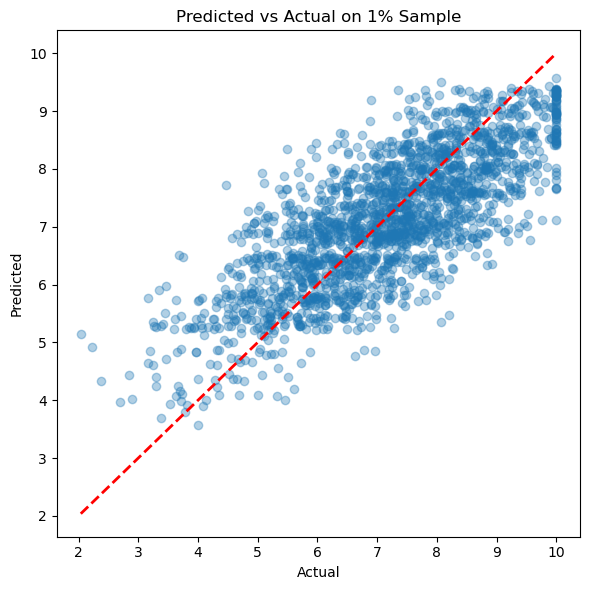

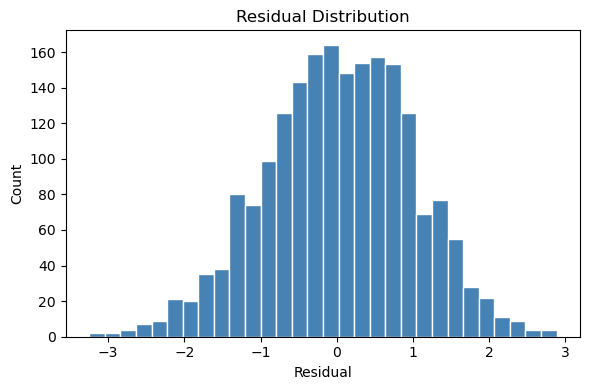

In [45]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.35)
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual on 1% Sample')
plt.tight_layout()
plt.show()

residuals = y_test - pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

## Step 4: Visualize the Results

This final step shows how close the predictions are to the actual values and how the residuals are distributed.